In [143]:
import tensorflow as tf
import numpy as np
import pandas as pd
from keras import Sequential
from keras.layers import Dense,Dropout, Activation , Flatten , Conv2D , MaxPooling2D
import matplotlib.pyplot as plt
from IPython.display import Image

In [144]:
digits_data= tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = digits_data.load_data()

In [145]:
print(x_train.shape)
print(x_test.shape)

(60000, 28, 28)
(10000, 28, 28)


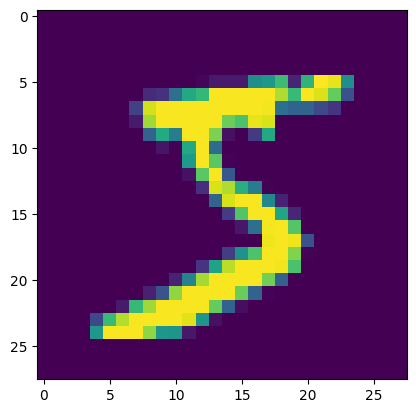

In [146]:
plt.imshow(x_train[0])

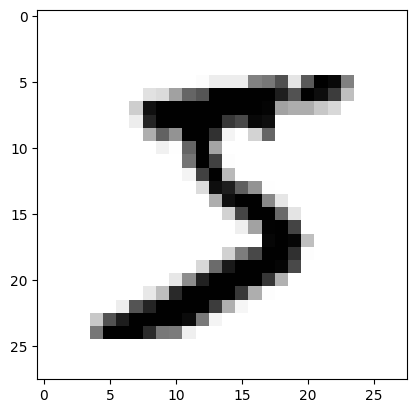

In [147]:
plt.imshow(x_train[0], cmap=plt.cm.binary)

In [148]:
x_train = tf.keras.utils.normalize(x_train, axis=1)
x_test = tf.keras.utils.normalize(x_test, axis=1)

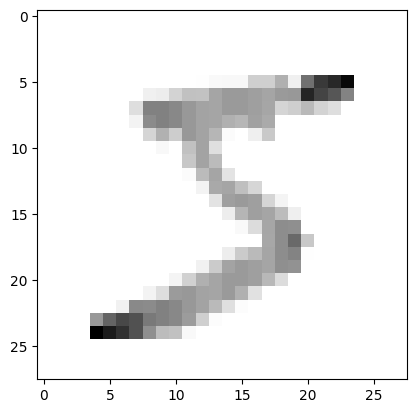

In [149]:
plt.imshow(x_train[0],cmap=plt.cm.binary)

In [150]:
image_size= 28
x_train = x_train.reshape(-1, image_size, image_size, 1)
x_test = x_test.reshape(-1, image_size, image_size, 1)

In [151]:
model = Sequential()
model.add(Conv2D(64, (3,3), input_shape = x_train.shape[1:]))
model.add(Activation("relu"))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(64, (3,3)))
model.add(Activation("relu"))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())
model.add(Dense(64))

model.add(Dense(10))
model.add(Activation("softmax"))

model.compile(loss="sparse_categorical_crossentropy",
             optimizer="adam",
             metrics=["accuracy"])

In [153]:
model.fit(x_train, y_train, batch_size=32, epochs=3, validation_split=0.2)

Epoch 1/3
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 85s 55ms/step - accuracy: 0.8921 - loss: 0.3523 - val_accuracy: 0.9784 - val_loss: 0.0682
Epoch 2/3
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 86s 57ms/step - accuracy: 0.9818 - loss: 0.0588 - val_accuracy: 0.9772 - val_loss: 0.0759
Epoch 3/3
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 136s 53ms/step - accuracy: 0.9872 - loss: 0.0429 - val_accuracy: 0.9847 - val_loss: 0.0525


In [155]:
model.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9795 - loss: 0.0617


[0.049579039216041565, 0.9840999841690063]

In [162]:
predicted_classes = np.argmax(model.predict(x_test[0:5]), axis=1)
print(predicted_classes)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
[7 2 1 0 4]


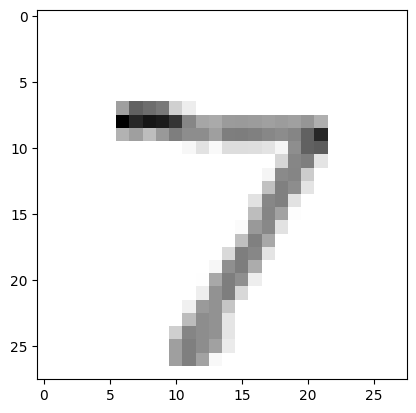

In [163]:
plt.imshow(x_test[0].reshape(28,28), cmap=plt.cm.binary)